<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Comprehensive_Hands_on_Tutorial_CNN_for_CIFAR_10_in_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Check if CUDA (GPU support) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1e6:.2f} MB")

Using device: cuda
GPU name: Tesla T4
Memory allocated: 0.00 MB


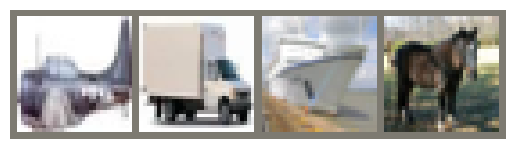

plane truck ship  horse


In [3]:
# Define transformations: convert to tensor and normalise
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL image to [0,1] float tensor
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # mean per channel
                         (0.2023, 0.1994, 0.2010))   # std per channel
])

# Download training and test sets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

# Create DataLoaders for batching and shuffling
batch_size = 128
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# Class names for reference
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Visualise a few sample images
def imshow(img):
    # Reverse the normalization
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    img = img * std + mean     # unnormalise

    # Clip to [0, 1] to avoid matplotlib warnings
    img = torch.clamp(img, 0, 1)

    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of training data
dataiter = iter(trainloader)
images, labels = next(dataiter)
# Show images
imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolutional block: input 3 channels -> output 32 feature maps
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Second block: 32 -> 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Third block: 64 -> 128 feature maps
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Max pooling layer (we'll reuse it)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully‑connected layers: after three poolings, image size becomes 4×4
        # (32 -> 16 -> 8 -> 4). With 128 channels, feature map size = 128*4*4 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)   # 10 output classes

    def forward(self, x):
        # Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the feature maps
        x = x.view(-1, 128 * 4 * 4)

        # Fully‑connected layers with ReLU on first, no activation on second (logits)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)   # raw scores (logits)
        return x

# Instantiate the model and move it to the GPU (if available)
model = CNN().to(device)
print(model)

# Count parameters (optional)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Total parameters: 620,362


In [5]:
# Loss function: CrossEntropyLoss (combines LogSoftmax and NLLLoss)
criterion = nn.CrossEntropyLoss()

# Optimizer: we'll use SGD with momentum (covered in next section)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Optionally, we can add a learning rate scheduler (not required now)

In [6]:
num_epochs = 10
train_losses = []
train_accuracies = []

print("Starting training...")
start_time = time.time()

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    # Set model to training mode (affects dropout/batchnorm if used)
    model.train()

    for i, data in enumerate(trainloader, 0):
        # Get inputs and labels; move them to the device (GPU)
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass (compute gradients)
        loss.backward()

        # Optimizer step (update parameters)
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

end_time = time.time()
print(f"Training finished in {end_time - start_time:.2f} seconds")

Starting training...
Epoch 1/10 | Loss: 1.6755 | Accuracy: 38.95%
Epoch 2/10 | Loss: 1.1773 | Accuracy: 58.15%
Epoch 3/10 | Loss: 0.9453 | Accuracy: 66.90%
Epoch 4/10 | Loss: 0.7922 | Accuracy: 72.34%
Epoch 5/10 | Loss: 0.6723 | Accuracy: 76.66%
Epoch 6/10 | Loss: 0.5703 | Accuracy: 80.18%
Epoch 7/10 | Loss: 0.4905 | Accuracy: 82.94%
Epoch 8/10 | Loss: 0.4017 | Accuracy: 85.72%
Epoch 9/10 | Loss: 0.3259 | Accuracy: 88.46%
Epoch 10/10 | Loss: 0.2573 | Accuracy: 90.97%
Training finished in 126.41 seconds


In [7]:
# Set model to evaluation mode (disables dropout, etc.)
model.eval()

correct = 0
total = 0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

# We don't need gradients for evaluation
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Per‑class accuracy
        c = (predicted == labels).squeeze()
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Print per‑class accuracy
for i in range(10):
    print(f"Accuracy of {classes[i]:>5s}: {100 * class_correct[i] / class_total[i]:.2f}%")

Test Accuracy: 75.55%
Accuracy of plane: 76.40%
Accuracy of   car: 80.70%
Accuracy of  bird: 71.20%
Accuracy of   cat: 60.50%
Accuracy of  deer: 71.20%
Accuracy of   dog: 61.00%
Accuracy of  frog: 81.30%
Accuracy of horse: 83.50%
Accuracy of  ship: 84.90%
Accuracy of truck: 84.80%


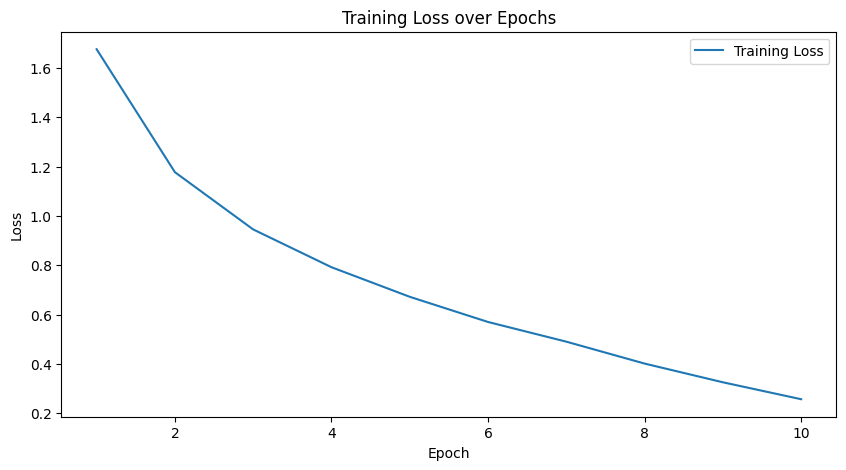

In [8]:
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()